# Community Biological Enrichment Analysis

This notebook reads the community assignment CSVs already produced by the community detection pipeline and runs:
1. **GO enrichment** (Biological Process, Molecular Function, Cellular Component, KEGG, Reactome) via g:Profiler
2. **Disease gene overlap** with DisGeNET
3. **Summary table** per cancer × algorithm combining both

All five algorithms are analysed: `louvain`, `greedy`, `leiden`, `infomap`, `DCSBM`

## 0. Imports and Paths

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg', force=True)
import matplotlib.pyplot as plt
plt.ioff()
import matplotlib.cm as cm
from gprofiler import GProfiler
from src.utils import translate_genes_to_string_ids

BASE_DIR = os.path.abspath('.')
COMMUNITY_DIR = os.path.join(BASE_DIR, 'results', '3_community_detection')
ENRICHMENT_DIR = os.path.join(BASE_DIR, 'results', '3_community_detection', 'enrichment')
DISGENET_FILE = os.path.join(BASE_DIR, 'data', 'disgenet.tsv')

os.makedirs(ENRICHMENT_DIR, exist_ok=True)

CANCERS = ['breast', 'lung', 'ovarian']
ALGORITHMS = ['louvain', 'greedy', 'leiden', 'infomap', 'DCSBM']
MIN_COMMUNITY_SIZE = 5
TOP_N_COMMUNITIES = 15  # only enrich the N largest communities

## 1. Load Community Assignments

In [ ]:
assignments = {}

for cancer in CANCERS:
    path = os.path.join(COMMUNITY_DIR, f'{cancer}_community_assignments.csv')
    if not os.path.exists(path):
        print(f'WARNING: {path} not found {cancer}')
        continue
    df = pd.read_csv(path)
    assignments[cancer] = df
    print(f'{cancer}: {len(df)} nodes, columns: {list(df.columns)}')

breast: 1781 nodes, columns: ['node', 'louvain', 'greedy', 'leiden', 'infomap', 'DCSBM']
lung: 1684 nodes, columns: ['node', 'louvain', 'greedy', 'leiden', 'infomap', 'DCSBM']
ovarian: 1728 nodes, columns: ['node', 'louvain', 'greedy', 'leiden', 'infomap', 'DCSBM']


## 2. Load Disease Genes (DisGeNET)

In [ ]:
disgenet = pd.read_csv(DISGENET_FILE, sep='\t')

disease_genes = {}
for cancer in CANCERS:
    # 1. Get raw gene symbols
    raw_genes = disgenet[disgenet['disease'] == cancer]['Gene'].dropna().tolist()
    # 2. Translate to STRING IDs
    translated_genes = translate_genes_to_string_ids(raw_genes) if raw_genes else []
    # 3. Store as a set for fast overlap intersection later
    disease_genes[cancer] = set(translated_genes)

## 3. Helper Functions

In [ ]:
gp = GProfiler(return_dataframe=True)


def go_enrichment_for_algorithm(df_assignments, cancer, algorithm):
    """
    Run GO enrichment for every community in one algorithm column.
    Returns a concatenated DataFrame with all significant results.
    """
    if algorithm not in df_assignments.columns:
        print(f'  Column {algorithm} not found — skipping')
        return pd.DataFrame()

    labels = df_assignments[['node', algorithm]].copy()
    labels.columns = ['node', 'community']

    # Focus on the largest communities only
    top_communities = (
        labels['community'].value_counts()
        .head(TOP_N_COMMUNITIES)
        .index.tolist()
    )

    all_results = []
    for comm_id in top_communities:
        raw_genes = labels[labels['community'] == comm_id]['node'].tolist()
        
        if len(raw_genes) < MIN_COMMUNITY_SIZE:
            continue
            
        # FIX: Strip the '9606.' prefix so g:Profiler recognizes the Ensembl IDs
        clean_genes = [g.replace('9606.', '') for g in raw_genes]
        
        try:
            result = gp.profile(
                organism='hsapiens',
                query=clean_genes,  # Pass the cleaned IDs here!
                sources=['GO:BP', 'GO:MF', 'GO:CC', 'KEGG', 'REAC'],
                significance_threshold_method='fdr',
                user_threshold=0.05,
                no_evidences=False
            )
            if result.empty:
                continue
            result['community']      = comm_id
            result['community_size'] = len(raw_genes)
            result['cancer']         = cancer
            result['algorithm']      = algorithm
            all_results.append(result)
        except Exception as e:
            print(f'  Enrichment failed for community {comm_id}: {e}')

    if not all_results:
        return pd.DataFrame()

    df = pd.concat(all_results, ignore_index=True)
    keep = ['cancer', 'algorithm', 'community', 'community_size',
            'source', 'name', 'p_value', 'significant',
            'intersection_size', 'term_size', 'query_size']
    df = df[[c for c in keep if c in df.columns]]
    return df[df['significant'] == True].sort_values(['community', 'p_value'])


def disease_overlap_for_algorithm(df_assignments, cancer, algorithm):
    """
    For each community, compute overlap with known disease genes.
    """
    if algorithm not in df_assignments.columns:
        return pd.DataFrame()

    labels = df_assignments[['node', algorithm]].copy()
    labels.columns = ['node', 'community']
    disease_set = disease_genes.get(cancer, set())

    rows = []
    for comm_id, grp in labels.groupby('community'):
        comm_genes = set(grp['node'].tolist())
        overlap    = comm_genes & disease_set
        rows.append({
            'cancer':            cancer,
            'algorithm':         algorithm,
            'community':         comm_id,
            'community_size':    len(comm_genes),
            'n_disease_genes':   len(overlap),
            'overlap_fraction':  len(overlap) / len(comm_genes) if comm_genes else 0,
            'disease_genes_in_community': ', '.join(sorted(overlap))
        })

    return pd.DataFrame(rows).sort_values('overlap_fraction', ascending=False)


def build_summary(go_df, overlap_df):
    """
    Combine top GO:BP term + top KEGG term + disease overlap into one summary table.
    """
    if go_df.empty:
        return overlap_df.copy()

    top_bp = (
        go_df[go_df['source'] == 'GO:BP']
        .sort_values('p_value')
        .groupby(['cancer', 'algorithm', 'community'])
        .first()[['name', 'p_value']]
        .reset_index()
        .rename(columns={'name': 'top_GO_BP', 'p_value': 'GO_BP_pval'})
    )
    top_kegg = (
        go_df[go_df['source'] == 'KEGG']
        .sort_values('p_value')
        .groupby(['cancer', 'algorithm', 'community'])
        .first()[['name', 'p_value']]
        .reset_index()
        .rename(columns={'name': 'top_KEGG', 'p_value': 'KEGG_pval'})
    )

    summary = overlap_df[['cancer', 'algorithm', 'community',
                           'community_size', 'n_disease_genes', 'overlap_fraction']].copy()
    summary = summary.merge(top_bp,   on=['cancer', 'algorithm', 'community'], how='left')
    summary = summary.merge(top_kegg, on=['cancer', 'algorithm', 'community'], how='left')
    return summary.sort_values(['cancer', 'algorithm', 'overlap_fraction'], ascending=[True, True, False])

## 4. Run Enrichment for All Cancers × All Algorithms

In [ ]:
all_go       = []
all_overlap  = []
all_summary  = []

for cancer in CANCERS:
    if cancer not in assignments:
        continue
    df_asgn = assignments[cancer]
    print(f'\n=== {cancer.upper()} ===')

    for algo in ALGORITHMS:
        print(f'  [{algo}] running enrichment...')

        go_df      = go_enrichment_for_algorithm(df_asgn, cancer, algo)
        overlap_df = disease_overlap_for_algorithm(df_asgn, cancer, algo)
        summary_df = build_summary(go_df, overlap_df)

        if not go_df.empty:
            all_go.append(go_df)
            go_df.to_csv(
                os.path.join(ENRICHMENT_DIR, f'{cancer}_{algo}_go_enrichment.csv'),
                index=False
            )
            print(f'    GO: {len(go_df)} significant terms across {go_df.community.nunique()} communities')
        else:
            print(f'    GO: no significant results')

        if not overlap_df.empty:
            all_overlap.append(overlap_df)
            overlap_df.to_csv(
                os.path.join(ENRICHMENT_DIR, f'{cancer}_{algo}_disease_overlap.csv'),
                index=False
            )

        if not summary_df.empty:
            all_summary.append(summary_df)
            summary_df.to_csv(
                os.path.join(ENRICHMENT_DIR, f'{cancer}_{algo}_community_summary.csv'),
                index=False
            )

# Master files combining everything
master_go      = pd.concat(all_go,      ignore_index=True) if all_go      else pd.DataFrame()
master_overlap = pd.concat(all_overlap, ignore_index=True) if all_overlap else pd.DataFrame()
master_summary = pd.concat(all_summary, ignore_index=True) if all_summary else pd.DataFrame()

master_go.to_csv(     os.path.join(ENRICHMENT_DIR, 'all_go_enrichment.csv'),      index=False)
master_overlap.to_csv(os.path.join(ENRICHMENT_DIR, 'all_disease_overlap.csv'),    index=False)
master_summary.to_csv(os.path.join(ENRICHMENT_DIR, 'all_community_summary.csv'),  index=False)

print('\nDone. All files saved to', ENRICHMENT_DIR)


=== BREAST ===
  [louvain] running enrichment...
    GO: no significant results
  [greedy] running enrichment...
    GO: no significant results
  [leiden] running enrichment...
    GO: no significant results
  [infomap] running enrichment...
    GO: no significant results
  [DCSBM] running enrichment...
    GO: no significant results

=== LUNG ===
  [louvain] running enrichment...
    GO: no significant results
  [greedy] running enrichment...
    GO: no significant results
  [leiden] running enrichment...
    GO: no significant results
  [infomap] running enrichment...
    GO: no significant results
  [DCSBM] running enrichment...
    GO: no significant results

=== OVARIAN ===
  [louvain] running enrichment...
    GO: no significant results
  [greedy] running enrichment...
    GO: no significant results
  [leiden] running enrichment...
    GO: no significant results
  [infomap] running enrichment...
    GO: no significant results
  [DCSBM] running enrichment...
    GO: no significan

## 5. Explore Results

### 5.1 Top GO terms per cancer and algorithm

In [ ]:
if not master_go.empty:
    for cancer in CANCERS:
        print(f'\n=== {cancer.upper()} — Top 5 GO:BP terms per algorithm ===')
        sub = master_go[(master_go['cancer'] == cancer) & (master_go['source'] == 'GO:BP')]
        for algo in ALGORITHMS:
            top = sub[sub['algorithm'] == algo].nsmallest(5, 'p_value')[['community', 'name', 'p_value']]
            if not top.empty:
                print(f'  {algo}:')
                print(top.to_string(index=False))
            else:
                print(f'  {algo}: no results')

### 5.2 Disease gene overlap — which communities are disease modules?

In [ ]:
if not master_overlap.empty:
    for cancer in CANCERS:
        print(f'\n=== {cancer.upper()} — Top disease-enriched communities per algorithm ===')
        sub = master_overlap[master_overlap['cancer'] == cancer]
        for algo in ALGORITHMS:
            top = (sub[sub['algorithm'] == algo]
                   .nlargest(3, 'overlap_fraction')
                   [['community', 'community_size', 'n_disease_genes', 'overlap_fraction']])
            if not top.empty:
                print(f'  {algo}:')
                print(top.to_string(index=False))
            else:
                print(f'  {algo}: no results')


=== BREAST — Top disease-enriched communities per algorithm ===
  louvain:
 community  community_size  n_disease_genes  overlap_fraction
         0               2                0               0.0
         1             319                0               0.0
         2             317                0               0.0
  greedy:
 community  community_size  n_disease_genes  overlap_fraction
         0             652                0               0.0
         1             618                0               0.0
         2             361                0               0.0
  leiden:
 community  community_size  n_disease_genes  overlap_fraction
         0             451                0               0.0
         1             352                0               0.0
         2             288                0               0.0
  infomap:
 community  community_size  n_disease_genes  overlap_fraction
         0               2                0               0.0
         1             10

### 5.3 Summary table — full community biology overview

In [ ]:
if not master_summary.empty:
    for cancer in CANCERS:
        for algo in ALGORITHMS:
            sub = master_summary[
                (master_summary['cancer'] == cancer) &
                (master_summary['algorithm'] == algo)
            ].head(10)
            if sub.empty:
                continue
            print(f'\n=== {cancer.upper()} | {algo} ===')
            display_cols = ['community', 'community_size', 'n_disease_genes',
                            'overlap_fraction', 'top_GO_BP', 'top_KEGG']
            print(sub[[c for c in display_cols if c in sub.columns]].to_string(index=False))


=== BREAST | louvain ===
 community  community_size  n_disease_genes  overlap_fraction
         0               2                0               0.0
         1             319                0               0.0
         2             317                0               0.0
         3             304                0               0.0
         4             284                0               0.0
         5              60                0               0.0
         6               2                0               0.0
         7              87                0               0.0
         8             210                0               0.0
         9             196                0               0.0

=== BREAST | greedy ===
 community  community_size  n_disease_genes  overlap_fraction
         0             652                0               0.0
         1             618                0               0.0
         2             361                0               0.0
         3         

## 6. Visualisation

### 6.1 Disease gene overlap fraction per community (top communities, all algorithms)

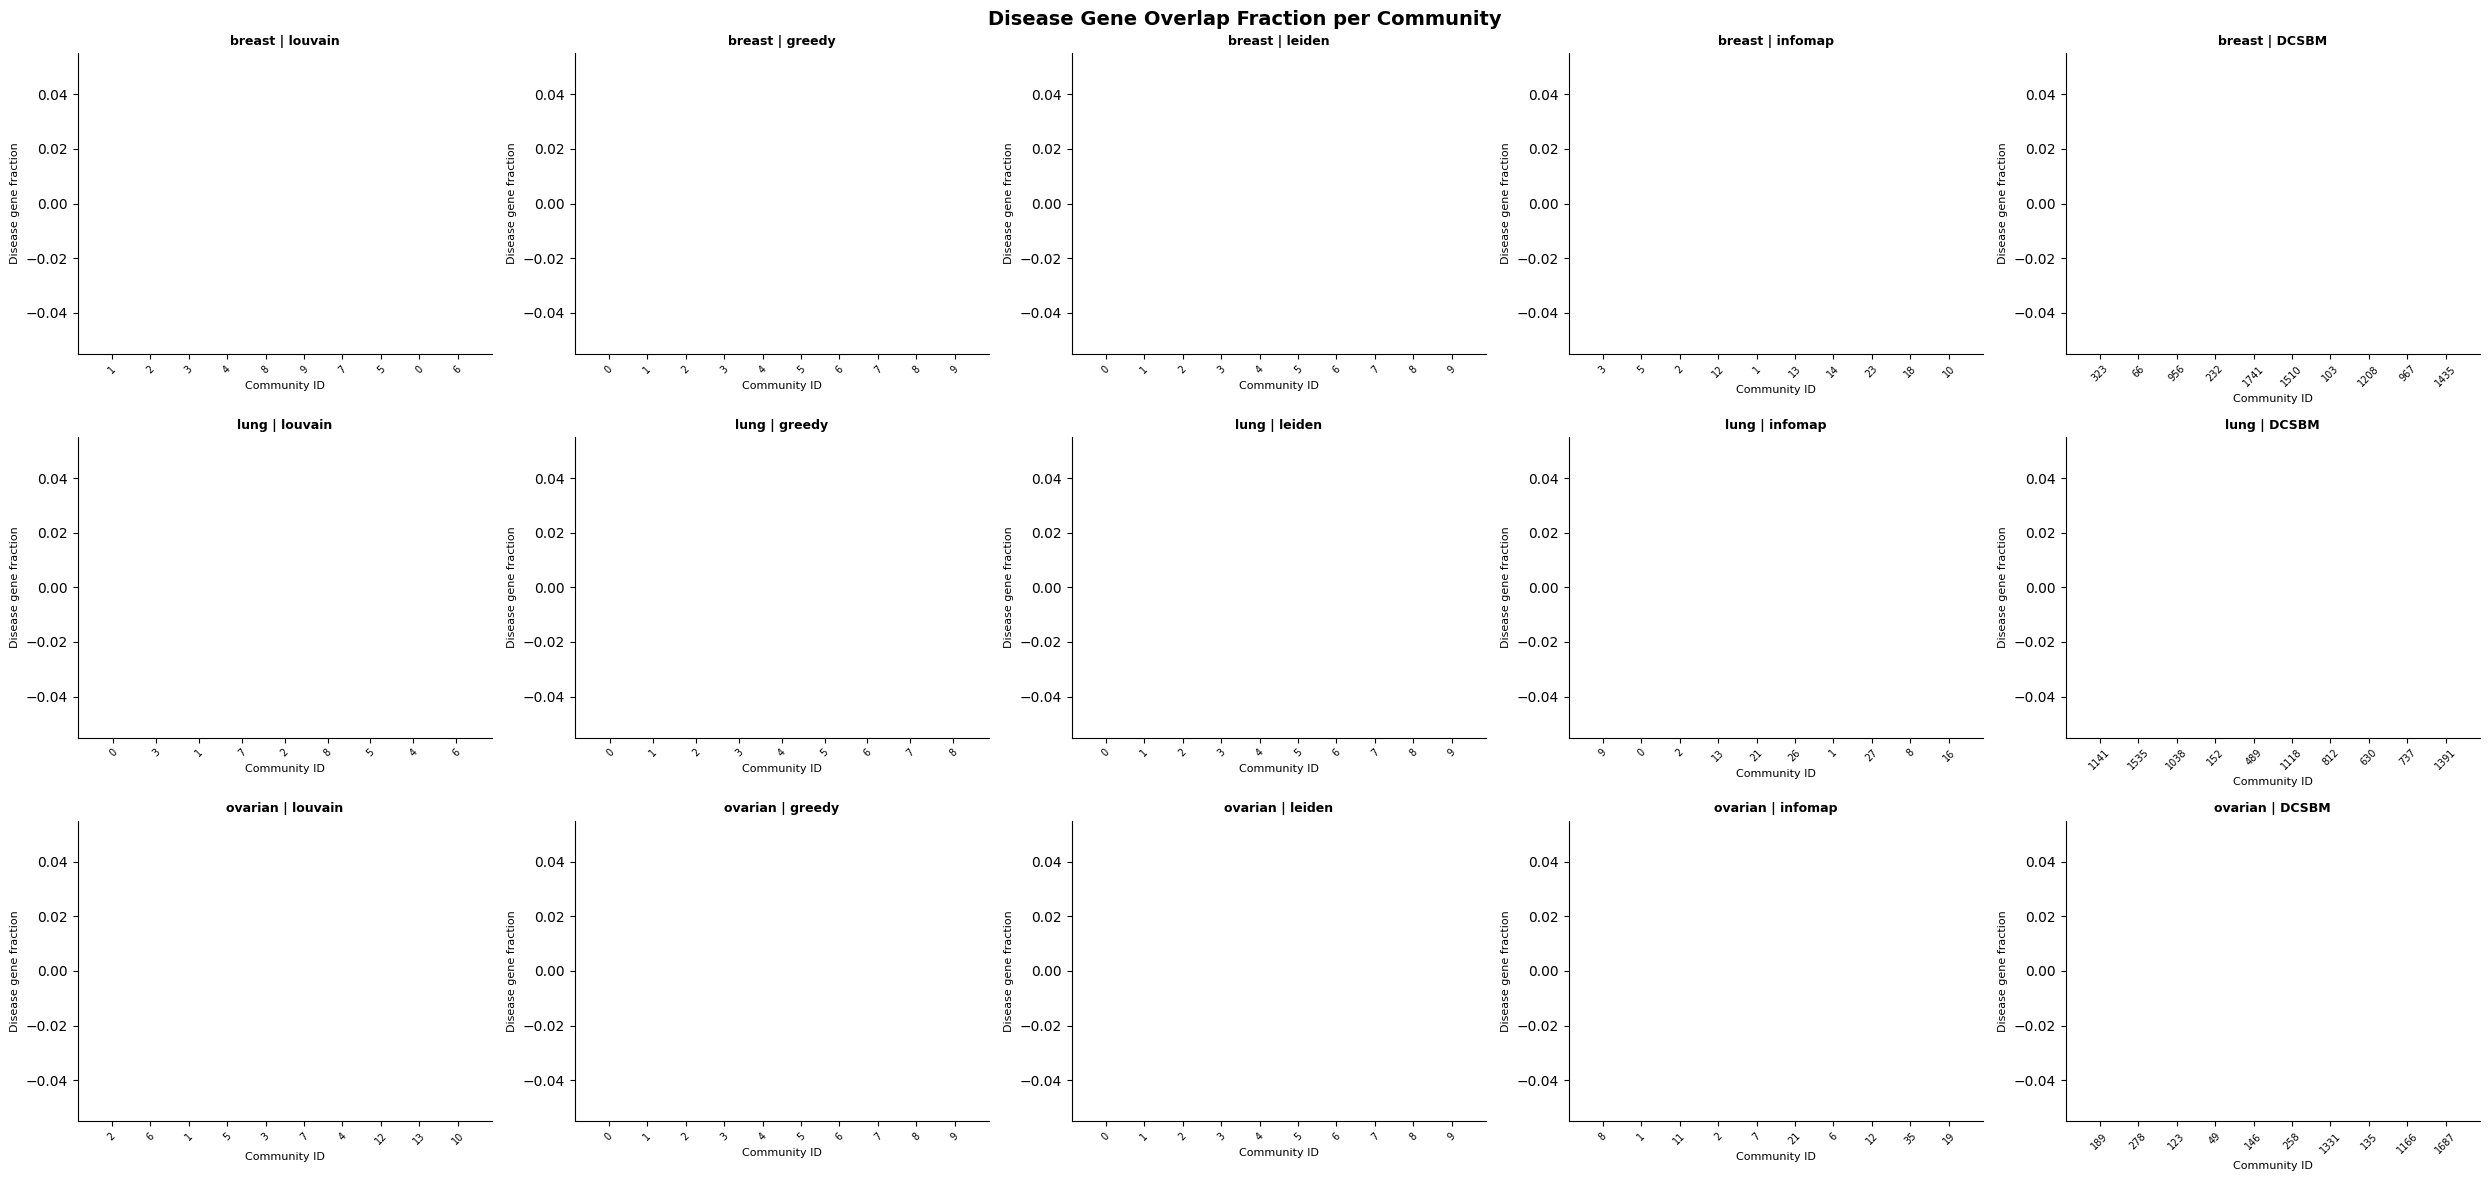

In [ ]:
if not master_overlap.empty:
    fig, axes = plt.subplots(len(CANCERS), len(ALGORITHMS),
                             figsize=(5 * len(ALGORITHMS), 4 * len(CANCERS)),
                             sharey=False)

    for i, cancer in enumerate(CANCERS):
        for j, algo in enumerate(ALGORITHMS):
            ax = axes[i][j]
            sub = (master_overlap[
                       (master_overlap['cancer'] == cancer) &
                       (master_overlap['algorithm'] == algo)
                   ]
                   .nlargest(10, 'community_size'))

            if sub.empty:
                ax.set_visible(False)
                continue

            colors = ['darkblue' if f > 0.1 else 'lightblue'
                      for f in sub['overlap_fraction']]
            ax.bar(sub['community'].astype(str), sub['overlap_fraction'], color=colors)
            ax.set_title(f'{cancer.capitalize()} | {algo}', fontsize=9, fontweight='bold')
            ax.set_xlabel('Community ID', fontsize=8)
            ax.set_ylabel('Disease gene fraction', fontsize=8)
            ax.tick_params(axis='x', rotation=45, labelsize=7)
            ax.spines[['top', 'right']].set_visible(False)

    fig.suptitle('DISEASE GENE OVERLAP FRACTION PER COMMUNITY',
                 fontsize=14, fontweight='bold')
    fig.tight_layout()
    plt.savefig(os.path.join(ENRICHMENT_DIR, 'disease_overlap_all.png'),
                dpi=300, bbox_inches='tight')
    plt.close(fig)
    plt.close('all')

### 6.2 Number of significant GO terms per community (GO:BP only)

In [ ]:
if not master_go.empty:
    go_bp = master_go[master_go['source'] == 'GO:BP']
    counts = (go_bp.groupby(['cancer', 'algorithm', 'community'])
                   .size()
                   .reset_index(name='n_significant_terms'))

    fig, axes = plt.subplots(len(CANCERS), len(ALGORITHMS),
                             figsize=(5 * len(ALGORITHMS), 4 * len(CANCERS)),
                             sharey=False)

    for i, cancer in enumerate(CANCERS):
        for j, algo in enumerate(ALGORITHMS):
            ax = axes[i][j]
            sub = counts[
                (counts['cancer'] == cancer) &
                (counts['algorithm'] == algo)
            ].nlargest(10, 'n_significant_terms')

            if sub.empty:
                ax.set_visible(False)
                continue

            ax.bar(sub['community'].astype(str), sub['n_significant_terms'],
                   color='cornflowerblue')
            ax.set_title(f'{cancer.capitalize()} | {algo}', fontsize=9, fontweight='bold')
            ax.set_xlabel('Community ID', fontsize=8)
            ax.set_ylabel('N significant GO:BP terms', fontsize=8)
            ax.tick_params(axis='x', rotation=45, labelsize=7)
            ax.spines[['top', 'right']].set_visible(False)

    fig.suptitle('NUMBER OF SIGNIFICANT GO:BP TERMS PER COMMUNITY',
                 fontsize=14, fontweight='bold')
    fig.tight_layout()
    plt.savefig(os.path.join(ENRICHMENT_DIR, 'go_terms_per_community.png'),
                dpi=300, bbox_inches='tight')
    plt.close(fig)
    plt.close('all')